# Étape 2 — Augmentation des données (Albumentations — `pill`)

TP B6, partie 1. Pipeline appliqué uniquement aux images **saines d'entraînement**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from indusense.vision.augment import augment_image, build_augmentation_pipeline
from indusense.vision.dataset import DEFAULT_IMAGE_SIZE, load_good_images

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

good_train = load_good_images("train", DEFAULT_IMAGE_SIZE)
pipeline = build_augmentation_pipeline()

D:\ProjetsIA\AELION_Deep_Learning_IA\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Livrable — original vs versions augmentées

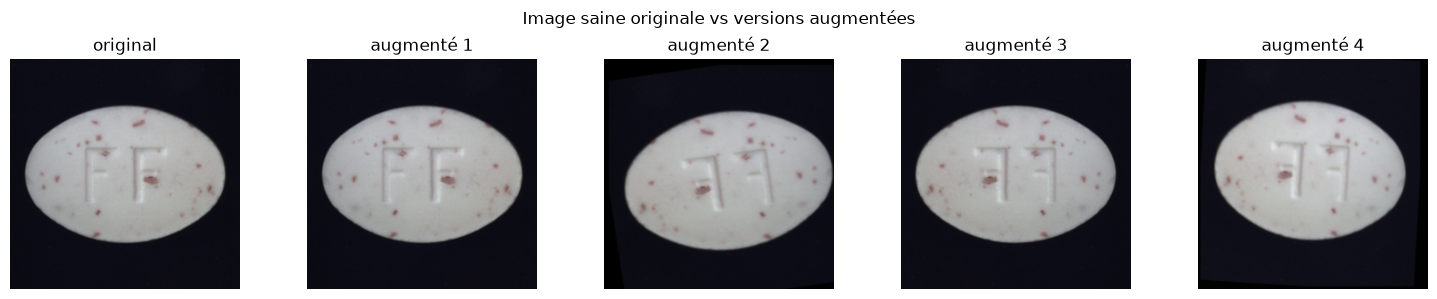

In [2]:
n_variants = 4
original = good_train[0]
variants = augment_image(original, pipeline, n=n_variants)

fig, axes = plt.subplots(1, n_variants + 1, figsize=(3 * (n_variants + 1), 3))
axes[0].imshow(original)
axes[0].set_title("original")
axes[0].axis("off")
for i, variant in enumerate(variants, start=1):
    axes[i].imshow(variant)
    axes[i].set_title(f"augmenté {i}")
    axes[i].axis("off")
fig.suptitle("Image saine originale vs versions augmentées")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_augmentations.png", dpi=150)
plt.show()

## Justification des transformations retenues (et écartées)

`pill` est un objet **centré et aligné** (comme `bottle`), pas une texture : chaque image
montre une pilule unique, cadrée de façon quasi identique par la caméra industrielle.

**Retenues, amplitudes modérées** :
- **Flips horizontal/vertical** : une pilule vue de dessus reste plausible retournée —
  n'introduit aucune ambiguïté avec les défauts recherchés (`crack`, `scratch`,
  `contamination`, `color`, `faulty_imprint`).
- **Rotation légère (±15°) et translation/échelle modérées (±5 %)** : imite les petites
  variations de positionnement de la pièce sur la ligne, sans dépasser ce qu'une caméra
  fixe observerait réellement.
- **Variations de luminosité/contraste modérées** : reproduit les variations d'éclairage
  industriel (heure, usure des lampes) sans changer la texture de la pilule elle-même.

**Écartées ou limitées** :
- **Rotation forte (proche de 180° ou aléatoire sur 360°)** : sur un objet aligné, une
  rotation trop forte élargit artificiellement la notion de « normal » que l'auto-encodeur
  doit apprendre. Le risque direct : un défaut réel (ex. `crack`), une fois « caché » dans
  une orientation inhabituelle mais couverte par l'augmentation, serait bien reconstruit par
  le modèle — donc **non détecté**. C'est l'inverse de l'effet recherché.
- **Distorsions élastiques / déformations fortes** : pertinentes pour des textures
  (tissus, surfaces irrégulières) où la déformation locale ne change pas la nature de
  l'objet, mais inadaptées ici : la forme et les bords nets de la pilule sont eux-mêmes
  des indices de défaut (`crack`, `scratch`) qu'il ne faut pas brouiller.

**Point de réflexion (objet vs texture)** : sur une catégorie *texture* (ex. `carpet`,
`wood`), une augmentation géométrique forte (rotation libre, crop aléatoire) est
généralement plus acceptable — la texture est localement invariante par rotation/translation.
Sur un objet *centré et aligné* comme `pill`, l'augmentation géométrique doit rester modérée
sous peine d'élargir la notion de « normal » au point de masquer les défauts recherchés.